## SEED 2026 analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

import torch
from sklearn.metrics import accuracy_score, f1_score


CHECKPOINT_DIR       = Path("../checkpoints_CNN/checkpoints_2026")
CHECKPOINT_DIR_MULTI = Path("../checkpoints_CNN/checkpoints_multiSeed")
FIGURES_DIR          = Path("../checkpoints_CNN/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SEED        = 2026
NUM_CLASSES = 75
DEVICE      = "cpu"

print(f"Checkpoint dir        : {CHECKPOINT_DIR}")
print(f"Checkpoint dir (multi): {CHECKPOINT_DIR_MULTI}")
print(f"Figures dir           : {FIGURES_DIR}")

Checkpoint dir        : ../checkpoints_CNN/checkpoints_2026
Checkpoint dir (multi): ../checkpoints_CNN/checkpoints_multiSeed
Figures dir           : ../checkpoints_CNN/figures


In [2]:
def load_checkpoints(directory: Path) -> tuple[dict, dict]:
    """
    Carrega todos os checkpoints CNN de um directório.
    Retorna dois dicts separados: histories e metrics.
    
    Estrutura esperada de cada .pt:
        {
            "model_state": ...,   # não carregamos — só análise
            "history":    {...},  # train/val loss, acc, lr por epoch
            "metrics":    {...}   # accuracy, f1_macro, f1_weighted (val final)
        }
    """
    histories = {}
    metrics   = {}

    for path in sorted(directory.glob("*.pt")):
        ckpt     = torch.load(path, map_location=DEVICE, weights_only=False)
        run_name = path.stem

        histories[run_name] = ckpt["history"]
        metrics[run_name]   = ckpt["metrics"]

        epochs   = len(ckpt["history"]["train_loss"])
        best_acc = max(ckpt["history"]["val_acc"])
        f1_mac   = ckpt["metrics"]["f1_macro"]

        print(f"  {run_name:<40} | epochs: {epochs:>3} "
              f"| best_val_acc: {best_acc:.4f} | f1_macro: {f1_mac:.4f}")

    print(f"\nTotal de runs carregados: {len(histories)}")
    return histories, metrics


histories, metrics = load_checkpoints(CHECKPOINT_DIR)

  alexnet_cel_adam                         | epochs:  30 | best_val_acc: 0.7317 | f1_macro: 0.7271
  alexnet_cel_rmsprop                      | epochs:  30 | best_val_acc: 0.7212 | f1_macro: 0.7160
  alexnet_mml_adam                         | epochs:  30 | best_val_acc: 0.6500 | f1_macro: 0.6412
  alexnet_mml_rmsprop                      | epochs:  30 | best_val_acc: 0.6529 | f1_macro: 0.6434
  alexnet_opt_cel_adam                     | epochs:  50 | best_val_acc: 0.8635 | f1_macro: 0.8629
  alexnet_opt_cel_rmsprop                  | epochs:  50 | best_val_acc: 0.8385 | f1_macro: 0.8350
  alexnet_opt_mml_adam                     | epochs:  50 | best_val_acc: 0.8048 | f1_macro: 0.8014
  alexnet_opt_mml_rmsprop                  | epochs:  50 | best_val_acc: 0.7971 | f1_macro: 0.7942
  alexnet_pre_cel_adam                     | epochs:  30 | best_val_acc: 0.9058 | f1_macro: 0.9051
  alexnet_pre_cel_rmsprop                  | epochs:  30 | best_val_acc: 0.8827 | f1_macro: 0.8811
  alexnet_

In [3]:
def summary_table(histories: dict, metrics: dict) -> pd.DataFrame:
    """
    Tabela consolidada de todos os runs, ordenada por val_acc desc e f1_macro desc.
    """
    rows = []
    for run_name, h in histories.items():
        m = metrics[run_name]
        rows.append({
            "run"          : run_name,
            "epochs"       : len(h["train_loss"]),
            "best_val_acc" : max(h["val_acc"]),
            "best_val_acc_epoch" : int(np.argmax(h["val_acc"])) + 1,
            "final_val_acc": h["val_acc"][-1],
            "best_val_loss": min(h["val_loss"]),
            "f1_macro"     : m["f1_macro"],
            "f1_weighted"  : m["f1_weighted"],
        })

    df = (pd.DataFrame(rows)
            .sort_values(["best_val_acc", "f1_macro"], ascending=False)
            .reset_index(drop=True))

    df.index += 1  # ranking começa em 1

    # Display formatado
    display(df.style
              .format({
                  "best_val_acc"      : "{:.4f}",
                  "final_val_acc"     : "{:.4f}",
                  "best_val_loss"     : "{:.4f}",
                  "f1_macro"          : "{:.4f}",
                  "f1_weighted"       : "{:.4f}",
              })
              .background_gradient(subset=["best_val_acc", "f1_macro"], cmap="YlGn")
              .set_caption("CNN Experiments — Ranked by Val Accuracy & F1 Macro"))

    return df


df_summary = summary_table(histories, metrics)

,run,epochs,best_val_acc,best_val_acc_epoch,final_val_acc,best_val_loss,f1_macro,f1_weighted
1,alexnet_pre_cel_adam,30,0.9058,26,0.9048,1.2002,0.9051,0.9048
2,vgg16_pre_cel_adam,30,0.8971,25,0.8923,1.2221,0.8979,0.8970
3,vgg16_pre_mml_rmsprop,30,0.8952,28,0.8894,0.0143,0.8943,0.8946
4,vgg16_pre_cel_rmsprop,30,0.8942,30,0.8942,1.2333,0.8939,0.8933
5,vgg16_pre_mml_adam,30,0.8885,24,0.8856,0.0152,0.8883,0.8880
6,alexnet_pre_cel_rmsprop,30,0.8827,25,0.8817,1.2620,0.8811,0.8807
7,alexnet_pre_mml_rmsprop,30,0.8731,29,0.8712,0.0191,0.8724,0.8724
8,alexnet_pre_mml_adam,29,0.8692,18,0.8654,0.0120,0.8679,0.8683
9,alexnet_opt_cel_adam,50,0.8635,42,0.8596,1.2535,0.8629,0.8636
10,alexnet_opt_cel_rmsprop,50,0.8385,46,0.8365,1.3192,0.8350,0.8360


In [4]:
def plot_individual(histories: dict, save_dir: Path = FIGURES_DIR):
    """
    Para cada run: 3 subplots — Loss, Accuracy, Learning Rate.
    Guarda cada figura em save_dir/individual/<run_name>.png
    """
    out_dir = save_dir / "individual"
    out_dir.mkdir(parents=True, exist_ok=True)

    for run_name, h in histories.items():
        epochs = range(1, len(h["train_loss"]) + 1)

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        fig.suptitle(run_name, fontsize=13, fontweight="bold", y=1.01)

        # ── Loss ──────────────────────────────────────────────────────
        ax = axes[0]
        ax.plot(epochs, h["train_loss"], "--", color="steelblue",  alpha=0.7, label="Train")
        ax.plot(epochs, h["val_loss"],   "-",  color="steelblue",  linewidth=1.8, label="Val")
        best_loss_ep = int(np.argmin(h["val_loss"])) + 1
        ax.axvline(best_loss_ep, color="steelblue", linestyle=":", alpha=0.5)
        ax.set_title("Loss")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

        # ── Accuracy ──────────────────────────────────────────────────
        ax = axes[1]
        ax.plot(epochs, h["train_acc"], "--", color="seagreen", alpha=0.7, label="Train")
        ax.plot(epochs, h["val_acc"],   "-",  color="seagreen", linewidth=1.8, label="Val")
        best_acc_ep  = int(np.argmax(h["val_acc"])) + 1
        best_acc_val = max(h["val_acc"])
        ax.axvline(best_acc_ep, color="seagreen", linestyle=":", alpha=0.5)
        ax.scatter(best_acc_ep, best_acc_val, color="seagreen", s=60, zorder=5,
                   label=f"Best: {best_acc_val:.4f} (ep {best_acc_ep})")
        ax.set_title("Accuracy")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

        # ── Learning Rate ─────────────────────────────────────────────
        ax = axes[2]
        ax.plot(epochs, h["lr"], "-", color="darkorange", linewidth=1.8)
        ax.set_title("Learning Rate")
        ax.set_xlabel("Epoch")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        fig.savefig(out_dir / f"{run_name}.png", dpi=150, bbox_inches="tight")
        plt.close(fig)

    print(f"Figuras guardadas em: {out_dir}")


plot_individual(histories)

Figuras guardadas em: ../checkpoints_CNN/figures/individual


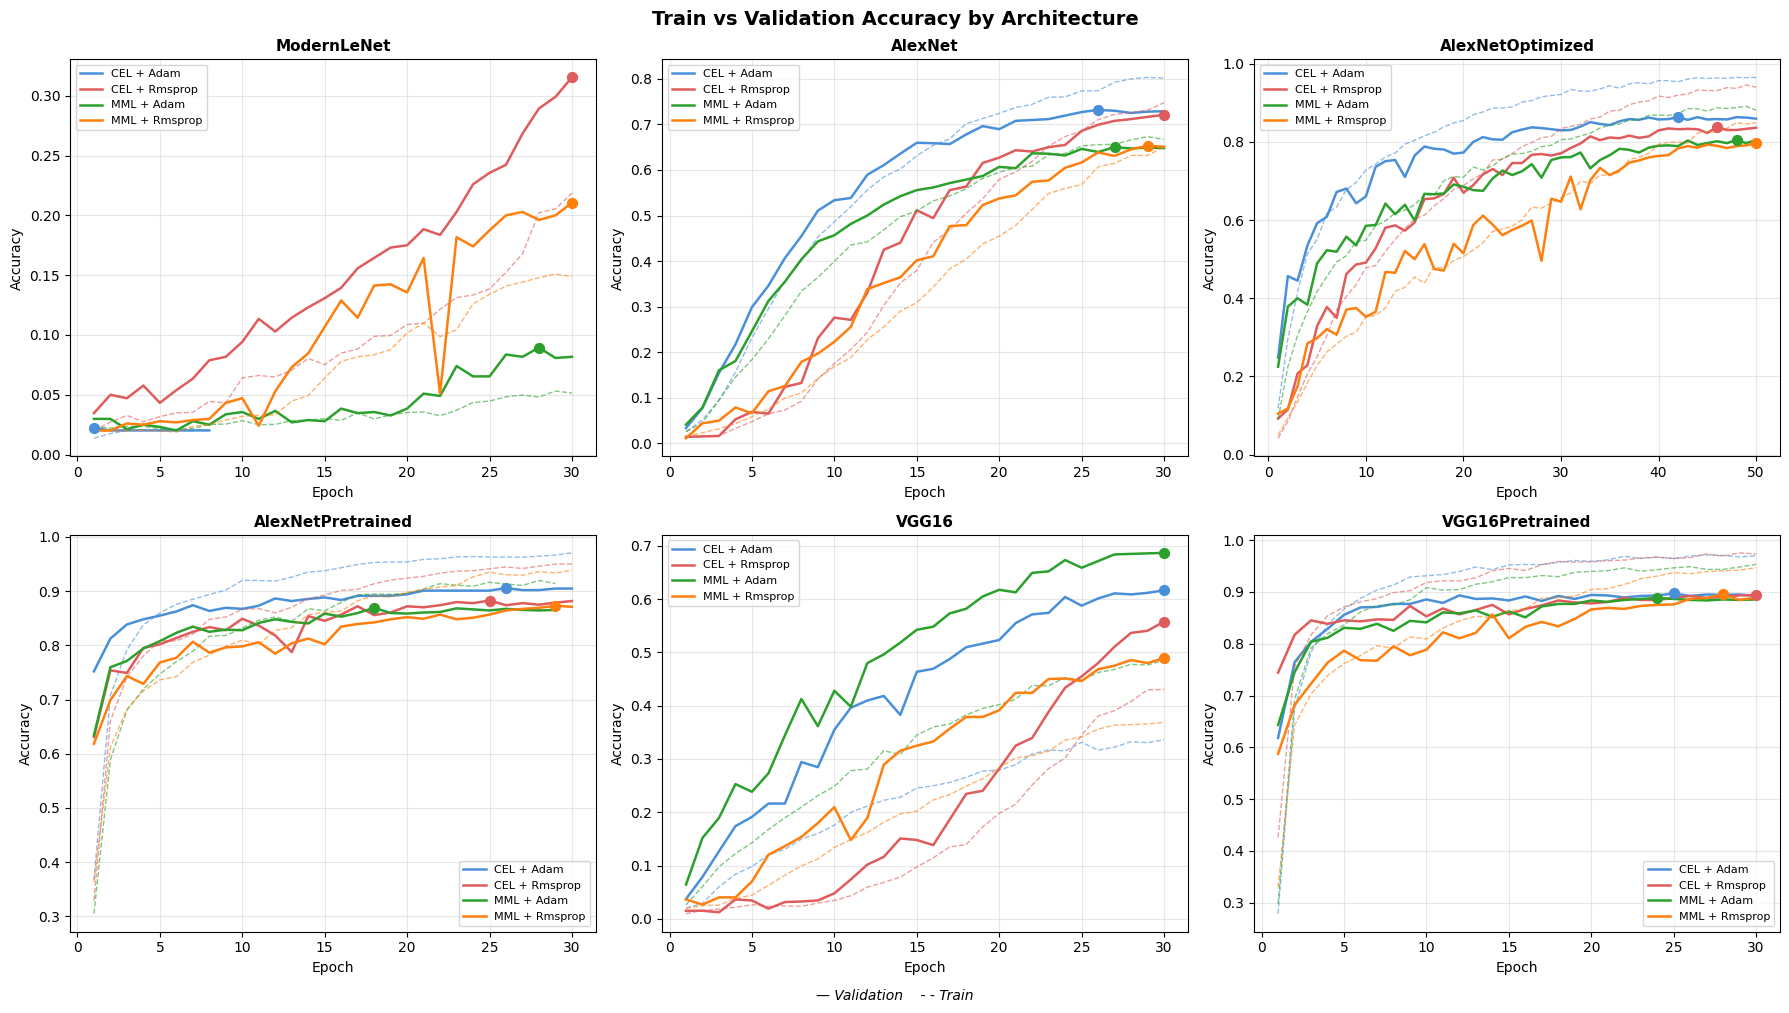

Figura guardada em: ../checkpoints_CNN/figures/val_by_architecture.png


In [5]:
def plot_by_architecture(histories: dict, save_dir: Path = FIGURES_DIR):
    """
    6 subplots — um por arquitectura.
    Cor identifica a combinação loss/optim.
    Linha sólida = Val acc, tracejado = Train acc.
    """
    architectures = {
        "ModernLeNet"      : "modernlenet",
        "AlexNet"          : "alexnet_cel|alexnet_mml",
        "AlexNetOptimized" : "alexnet_opt",
        "AlexNetPretrained": "alexnet_pre",
        "VGG16"            : "vgg16_cel|vgg16_mml",
        "VGG16Pretrained"  : "vgg16_pre",
    }

    # cor por combinação loss+optim
    combo_colors = {
        "cel_adam"    : "#4a90d9",  # azul
        "cel_rmsprop" : "#e05c5c",  # vermelho
        "mml_adam"    : "#2ca02c",  # verde
        "mml_rmsprop" : "#ff7f0e",  # laranja
    }

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Train vs Validation Accuracy by Architecture",
                 fontsize=14, fontweight="bold")
    axes = axes.flatten()

    for ax, (arch_name, prefix) in zip(axes, architectures.items()):
        arch_runs = {
            name: h for name, h in histories.items()
            if any(name.startswith(p) for p in prefix.split("|"))
            and not any(
                name.startswith(excl)
                for excl in prefix.split("|")
                for other_prefix in architectures.values()
                if other_prefix != prefix
                for excl_p in other_prefix.split("|")
                if name.startswith(excl_p) and not name.startswith(p)
            )
        }

        for name, h in arch_runs.items():
            epochs = range(1, len(h["val_acc"]) + 1)

            parts    = name.split("_")
            loss_key = "mml" if "mml" in parts else "cel"
            opt_key  = "rmsprop" if "rmsprop" in parts else "adam"
            combo    = f"{loss_key}_{opt_key}"
            color    = combo_colors[combo]
            label    = f"{loss_key.upper()} + {opt_key.capitalize()}"

            # Train acc — tracejado, linha fina
            ax.plot(epochs, h["train_acc"], linestyle="--", color=color,
                    linewidth=1.0, alpha=0.6)

            # Val acc — sólido, linha principal
            ax.plot(epochs, h["val_acc"], linestyle="-", color=color,
                    linewidth=1.8, label=label)

            best_ep  = int(np.argmax(h["val_acc"])) + 1
            best_val = max(h["val_acc"])
            ax.scatter(best_ep, best_val, color=color, s=50, zorder=5)

        ax.set_title(arch_name, fontsize=11, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    # legenda global para train vs val
    fig.text(0.5, -0.01,
             "— Validation    - - Train",
             ha="center", fontsize=10, style="italic")

    plt.tight_layout()
    fig.savefig(save_dir / "val_by_architecture.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Figura guardada em: {save_dir / 'val_by_architecture.png'}")


plot_by_architecture(histories)

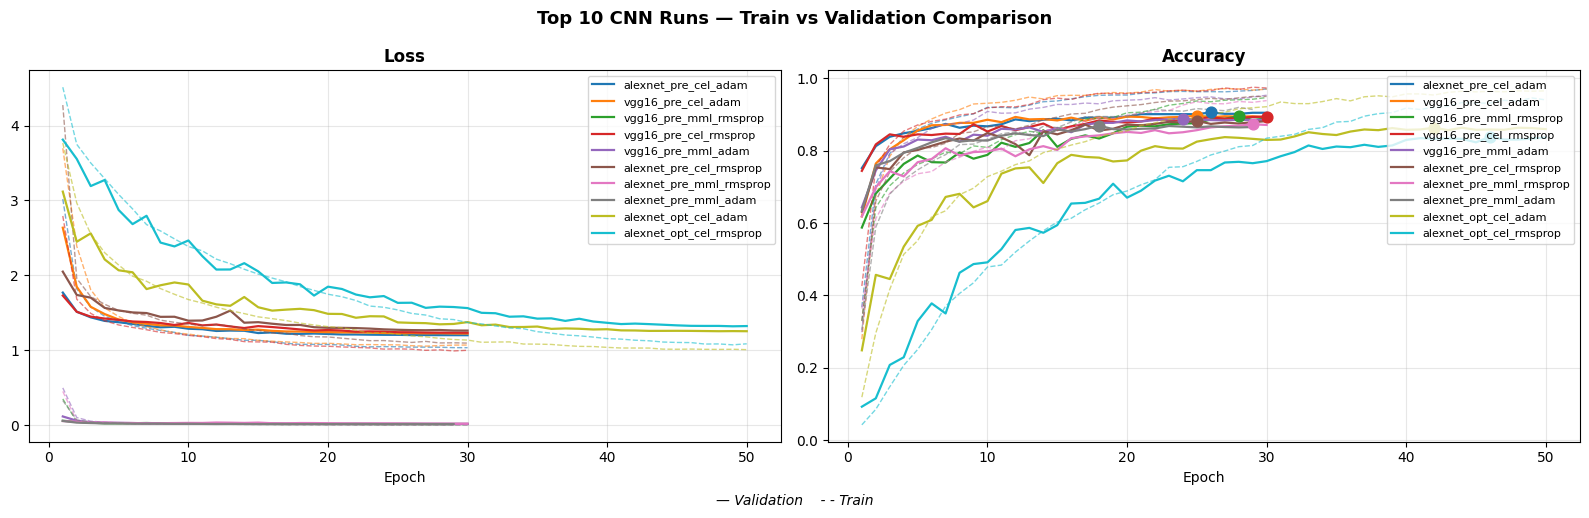

Figura guardada em: ../checkpoints_CNN/figures/val_top10.png


In [6]:
def plot_top_n(histories: dict, metrics: dict, n: int = 10, save_dir: Path = FIGURES_DIR):
    """
    Top N runs por best_val_acc — val_loss e val_acc sobrepostos.
    Linha sólida = Val, tracejado = Train.
    """
    sorted_runs = sorted(histories.keys(),
                         key=lambda name: max(histories[name]["val_acc"]),
                         reverse=True)[:n]

    cmap   = plt.get_cmap("tab10")
    colors = {name: cmap(i % 10) for i, name in enumerate(sorted_runs)}

    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"Top {n} CNN Runs — Train vs Validation Comparison",
                 fontsize=13, fontweight="bold")

    for name in sorted_runs:
        h      = histories[name]
        color  = colors[name]
        epochs = range(1, len(h["val_loss"]) + 1)

        # Train — tracejado, linha fina
        ax_loss.plot(epochs, h["train_loss"], linestyle="--", color=color,
                     linewidth=1.0, alpha=0.6)
        ax_acc.plot(epochs,  h["train_acc"],  linestyle="--", color=color,
                    linewidth=1.0, alpha=0.6)

        # Val — sólido, linha principal
        ax_loss.plot(epochs, h["val_loss"], linestyle="-", color=color,
                     linewidth=1.6, label=name)
        ax_acc.plot(epochs,  h["val_acc"],  linestyle="-", color=color,
                    linewidth=1.6, label=name)

        best_ep  = int(np.argmax(h["val_acc"])) + 1
        best_val = max(h["val_acc"])
        ax_acc.scatter(best_ep, best_val, color=color, s=60, zorder=5)

    for ax, title in zip([ax_loss, ax_acc], ["Loss", "Accuracy"]):
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="upper right")

    fig.text(0.5, -0.01,
             "— Validation    - - Train",
             ha="center", fontsize=10, style="italic")

    plt.tight_layout()
    fig.savefig(save_dir / f"val_top{n}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Figura guardada em: {save_dir / f'val_top{n}.png'}")


plot_top_n(histories, metrics, n=10)

In [7]:
def compare_two(name_a: str, name_b: str,
                histories: dict, metrics: dict,
                save_dir: Path = FIGURES_DIR):
    """
    Comparação directa entre dois runs — 4 subplots:
    Train Loss, Val Loss, Train Accuracy, Val Accuracy.
    Inclui anotação com métricas finais (acc, f1_macro, f1_weighted).
    """
    assert name_a in histories, f"'{name_a}' não encontrado nos checkpoints."
    assert name_b in histories, f"'{name_b}' não encontrado nos checkpoints."

    ha, hb   = histories[name_a], histories[name_b]
    ma, mb   = metrics[name_a],   metrics[name_b]
    color_a  = "#4a90d9"
    color_b  = "#e05c5c"

    plot_keys = [
        ("train_loss", "Train Loss",     False),
        ("val_loss",   "Val Loss",       True),
        ("train_acc",  "Train Accuracy", False),
        ("val_acc",    "Val Accuracy",   True),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"Comparison: {name_a}  vs  {name_b}",
                 fontsize=13, fontweight="bold")
    axes = axes.flatten()

    for ax, (key, title, mark_best) in zip(axes, plot_keys):
        for name, h, color in [(name_a, ha, color_a), (name_b, hb, color_b)]:
            values = h[key]
            epochs = range(1, len(values) + 1)
            ax.plot(epochs, values, color=color, linewidth=1.8, label=name)

            if mark_best:
                if "acc" in key:
                    best_ep  = int(np.argmax(values)) + 1
                    best_val = max(values)
                else:
                    best_ep  = int(np.argmin(values)) + 1
                    best_val = min(values)
                ax.scatter(best_ep, best_val, color=color, s=70, zorder=5)
                ax.axvline(best_ep, color=color, linestyle=":", alpha=0.4)

        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    # ── Anotação com métricas finais ───────────────────────────────────
    def fmt_metrics(name, m):
        return (f"{name}\n"
                f"  Acc       : {m['accuracy']:.4f}\n"
                f"  F1 Macro  : {m['f1_macro']:.4f}\n"
                f"  F1 Weighted: {m['f1_weighted']:.4f}")

    fig.text(0.01, -0.02, fmt_metrics(name_a, ma),
             fontsize=9, color=color_a, family="monospace")
    fig.text(0.40, -0.02, fmt_metrics(name_b, mb),
             fontsize=9, color=color_b, family="monospace")

    plt.tight_layout()
    fname = f"compare_{name_a}_vs_{name_b}.png"
    fig.savefig(save_dir / fname, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Figura guardada em: {save_dir / fname}")


# Exemplo de uso — substitui pelos nomes que quiseres comparar
# compare_two("vgg16_cel_adam", "vgg16_pre_cel_adam", histories, metrics)

In [8]:
def export_report(histories: dict, metrics: dict,
                  save_dir: Path = FIGURES_DIR) -> pd.DataFrame:
    """
    Exporta CSV consolidado com todas as métricas por run.
    Ordenado por best_val_acc desc e f1_macro desc.
    Guarda em save_dir/cnn_experiments_report.csv
    """
    rows = []
    for run_name, h in histories.items():
        m = metrics[run_name]

        # extrair arquitectura, loss, optim do nome
        parts    = run_name.split("_")
        loss_key = "mml"  if "mml"     in parts else "cel"
        opt_key  = "rmsprop" if "rmsprop" in parts else "adam"

        # arquitectura = tudo antes de cel/mml
        loss_idx = parts.index("mml") if "mml" in parts else parts.index("cel")
        arch     = "_".join(parts[:loss_idx])

        rows.append({
            "run"               : run_name,
            "architecture"      : arch,
            "loss"              : loss_key.upper(),
            "optimizer"         : opt_key.capitalize(),
            "epochs_trained"    : len(h["train_loss"]),
            "best_val_acc"      : round(max(h["val_acc"]), 4),
            "best_val_acc_epoch": int(np.argmax(h["val_acc"])) + 1,
            "final_val_acc"     : round(h["val_acc"][-1], 4),
            "best_val_loss"     : round(min(h["val_loss"]), 4),
            "final_val_loss"    : round(h["val_loss"][-1], 4),
            "final_train_acc"   : round(h["train_acc"][-1], 4),
            "final_train_loss"  : round(h["train_loss"][-1], 4),
            "accuracy"          : round(m["accuracy"], 4),
            "f1_macro"          : round(m["f1_macro"], 4),
            "f1_weighted"       : round(m["f1_weighted"], 4),
        })

    df = (pd.DataFrame(rows)
            .sort_values(["best_val_acc", "f1_macro"], ascending=False)
            .reset_index(drop=True))
    df.index += 1

    out_path = save_dir / "cnn_experiments_report.csv"
    df.to_csv(out_path, index_label="rank")
    print(f"Report guardado em: {out_path}")
    display(df)
    return df


df_report = export_report(histories, metrics)

Report guardado em: ../checkpoints_CNN/figures/cnn_experiments_report.csv


,run,architecture,loss,optimizer,epochs_trained,best_val_acc,best_val_acc_epoch,final_val_acc,best_val_loss,final_val_loss,final_train_acc,final_train_loss,accuracy,f1_macro,f1_weighted
1,alexnet_pre_cel_adam,alexnet_pre,CEL,Adam,30,0.9058,26,0.9048,1.2002,1.2002,0.9707,1.0335,0.9058,0.9051,0.9048
2,vgg16_pre_cel_adam,vgg16_pre,CEL,Adam,30,0.8971,25,0.8923,1.2221,1.2221,0.9699,1.0686,0.8971,0.8979,0.8970
3,vgg16_pre_mml_rmsprop,vgg16_pre,MML,Rmsprop,30,0.8952,28,0.8894,0.0143,0.0143,0.9469,0.0035,0.8952,0.8943,0.8946
4,vgg16_pre_cel_rmsprop,vgg16_pre,CEL,Rmsprop,30,0.8942,30,0.8942,1.2333,1.2333,0.9733,0.9988,0.8942,0.8939,0.8933
5,vgg16_pre_mml_adam,vgg16_pre,MML,Adam,30,0.8885,24,0.8856,0.0152,0.0154,0.9534,0.0056,0.8885,0.8883,0.8880
6,alexnet_pre_cel_rmsprop,alexnet_pre,CEL,Rmsprop,30,0.8827,25,0.8817,1.2620,1.2620,0.9500,1.0949,0.8827,0.8811,0.8807
7,alexnet_pre_mml_rmsprop,alexnet_pre,MML,Rmsprop,30,0.8731,29,0.8712,0.0191,0.0191,0.9384,0.0030,0.8731,0.8724,0.8724
8,alexnet_pre_mml_adam,alexnet_pre,MML,Adam,29,0.8692,18,0.8654,0.0120,0.0121,0.9139,0.0049,0.8692,0.8679,0.8683
9,alexnet_opt_cel_adam,alexnet_opt,CEL,Adam,50,0.8635,42,0.8596,1.2535,1.2535,0.9654,1.0074,0.8635,0.8629,0.8636
10,alexnet_opt_cel_rmsprop,alexnet_opt,CEL,Rmsprop,50,0.8385,46,0.8365,1.3192,1.3224,0.9404,1.0855,0.8385,0.8350,0.8360


## MultiSEED analysis

In [18]:
def load_multi_seed(models, seeds):
    data = {}
    for model in models:
        data[model] = {}
        for seed in seeds:
            path = get_ckpt_path(model, seed)
            if not path.exists():
                print(f"  [SKIP] {path}")
                continue
            ckpt = torch.load(path, map_location="cpu", weights_only=False)
            data[model][seed] = {
                "history": ckpt["history"],
                "metrics": ckpt["metrics"],
            }
            f1  = ckpt["metrics"]["f1_macro"]
            acc = ckpt["metrics"]["accuracy"]
            print(f"  {model} | seed {seed:>4} | F1-macro: {f1:.4f} | Accuracy: {acc:.4f}")
    return data

load_multi_seed(MODELS, SEEDS);

  alexnet_pre_cel_adam | seed    0 | F1-macro: 0.9084 | Accuracy: 0.9087
  alexnet_pre_cel_adam | seed    1 | F1-macro: 0.9112 | Accuracy: 0.9125
  alexnet_pre_cel_adam | seed   42 | F1-macro: 0.9012 | Accuracy: 0.9019
  alexnet_pre_cel_adam | seed 1010 | F1-macro: 0.9059 | Accuracy: 0.9058
  alexnet_pre_cel_adam | seed 2026 | F1-macro: 0.9051 | Accuracy: 0.9058
  vgg16_pre_cel_adam | seed    0 | F1-macro: 0.9064 | Accuracy: 0.9058
  vgg16_pre_cel_adam | seed    1 | F1-macro: 0.9121 | Accuracy: 0.9125
  vgg16_pre_cel_adam | seed   42 | F1-macro: 0.9221 | Accuracy: 0.9212
  vgg16_pre_cel_adam | seed 1010 | F1-macro: 0.9159 | Accuracy: 0.9154
  vgg16_pre_cel_adam | seed 2026 | F1-macro: 0.8979 | Accuracy: 0.8971
  vgg16_pre_cel_rmsprop | seed    0 | F1-macro: 0.9074 | Accuracy: 0.9067
  vgg16_pre_cel_rmsprop | seed    1 | F1-macro: 0.9024 | Accuracy: 0.9029
  vgg16_pre_cel_rmsprop | seed   42 | F1-macro: 0.9028 | Accuracy: 0.9019
  vgg16_pre_cel_rmsprop | seed 1010 | F1-macro: 0.8941 | A

In [10]:
def pad_to_same_length(arrays):
    """Pad com o último valor para todas as curvas ficarem com o mesmo comprimento."""
    max_len = max(len(a) for a in arrays)
    padded  = []
    for a in arrays:
        a = np.array(a, dtype=float)
        if len(a) < max_len:
            a = np.concatenate([a, np.full(max_len - len(a), a[-1])])
        padded.append(a)
    return np.array(padded)  # shape: (n_seeds, max_len)

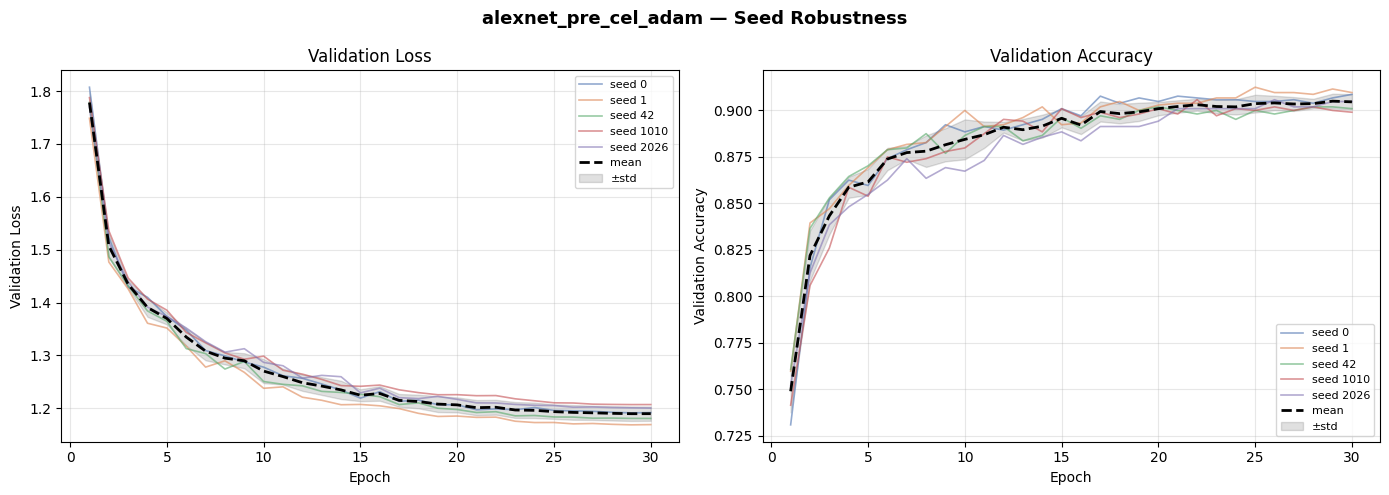

Saved: ../checkpoints_CNN/figures_multiSEED/alexnet_pre_cel_adam_seed_robustness.png


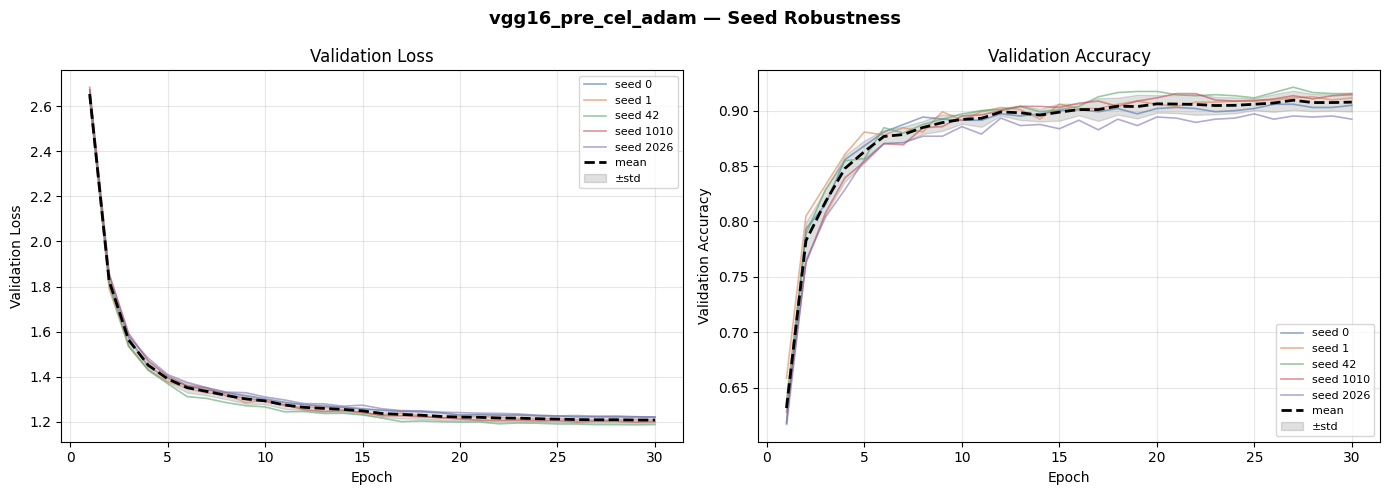

Saved: ../checkpoints_CNN/figures_multiSEED/vgg16_pre_cel_adam_seed_robustness.png


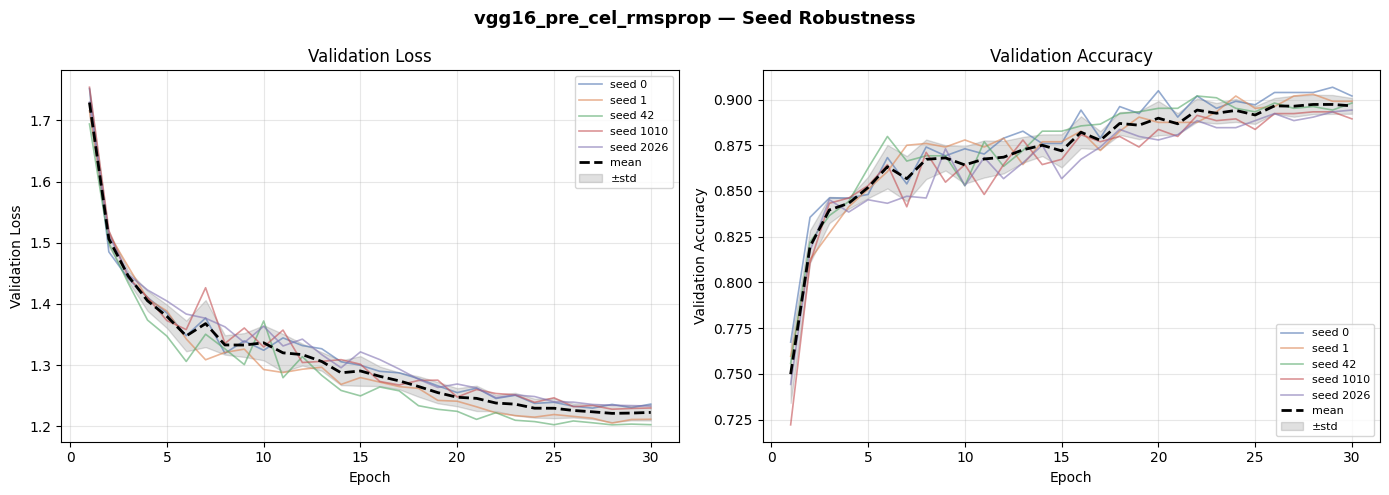

Saved: ../checkpoints_CNN/figures_multiSEED/vgg16_pre_cel_rmsprop_seed_robustness.png


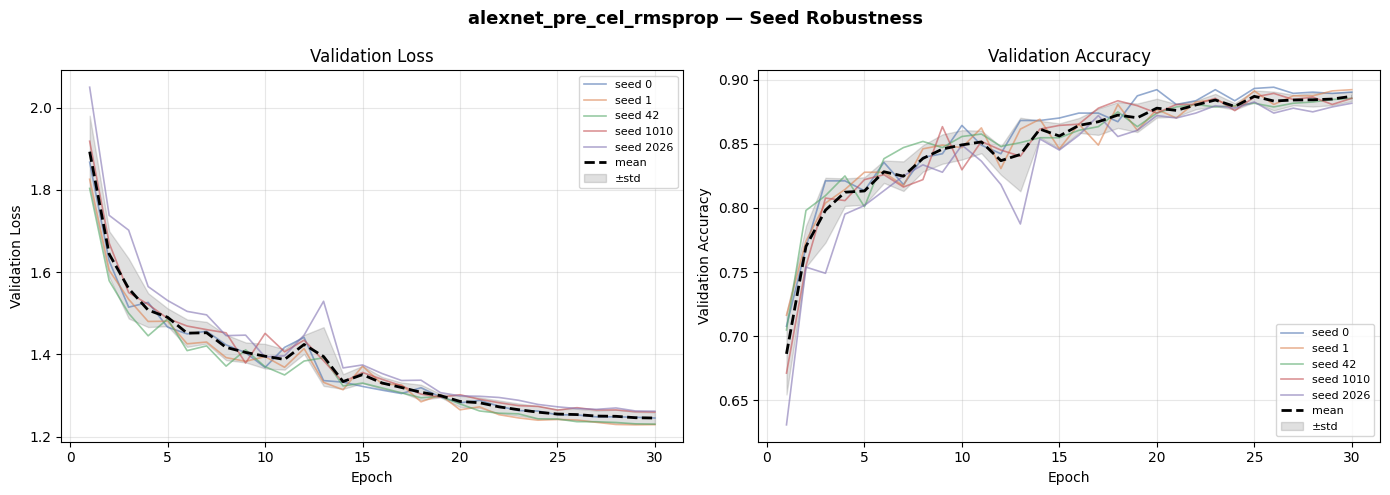

Saved: ../checkpoints_CNN/figures_multiSEED/alexnet_pre_cel_rmsprop_seed_robustness.png


In [15]:
def plot_seed_robustness(multi_data, save_dir=FIGURES_DIR_MULTI):
    for model_name, seed_dict in multi_data.items():
        if len(seed_dict) < 2:
            print(f"[SKIP] {model_name} — menos de 2 seeds carregadas")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"{model_name} — Seed Robustness", fontsize=13, fontweight="bold")

        for ax, metric_key, ylabel in [
            (axes[0], "val_loss", "Validation Loss"),
            (axes[1], "val_acc",  "Validation Accuracy"),
        ]:
            curves = []
            for seed, d in seed_dict.items():
                curve  = np.array(d["history"][metric_key])
                epochs = np.arange(1, len(curve) + 1)
                ax.plot(epochs, curve,
                        color=SEED_COLORS.get(seed, "gray"),
                        linewidth=1.2, alpha=0.6,
                        linestyle="-",
                        label=f"seed {seed}")
                curves.append(curve)

            min_len = min(len(c) for c in curves)
            padded  = np.array([c[:min_len] for c in curves])
            mean    = padded.mean(axis=0)
            std     = padded.std(axis=0)
            x       = np.arange(1, len(mean) + 1)

            ax.plot(x, mean, color="black", linewidth=2.0, linestyle="--", label="mean", zorder=5)
            ax.fill_between(x, mean - std, mean + std, color="black", alpha=0.12, label="±std")

            ax.set_title(ylabel)
            ax.set_xlabel("Epoch")
            ax.set_ylabel(ylabel)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        save_path = save_dir / f"{model_name}_seed_robustness.png"
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Saved: {save_path}")

plot_seed_robustness(multi_data)

In [12]:
def summary_multiseed(multi_data, seeds):
    rows = []
    for model_name, seed_dict in multi_data.items():
        row = {"model": model_name}
        f1_values = []
        for seed in seeds:
            if seed in seed_dict:
                f1 = seed_dict[seed]["metrics"]["f1_macro"]
                row[f"seed_{seed}"] = round(f1, 4)
                f1_values.append(f1)
            else:
                row[f"seed_{seed}"] = None
        row["mean"] = round(np.mean(f1_values), 4) if f1_values else None
        row["std"]  = round(np.std(f1_values),  4) if f1_values else None
        rows.append(row)

    df = pd.DataFrame(rows).sort_values("mean", ascending=False).reset_index(drop=True)
    df.index += 1

    display(df.style
              .format({f"seed_{s}": "{:.4f}" for s in seeds} | {"mean": "{:.4f}", "std": "{:.4f}"}, na_rep="N/A")
              .background_gradient(subset=["mean"], cmap="YlGn")
              .set_caption("MultiSEED — F1-Macro por modelo e seed"))
    return df

df_multi_summary = summary_multiseed(multi_data, SEEDS)

,model,seed_0,seed_1,seed_42,seed_1010,seed_2026,mean,std
1,vgg16_pre_cel_adam,0.9064,0.9121,0.9221,0.9159,0.8979,0.9109,0.0083
2,alexnet_pre_cel_adam,0.9084,0.9112,0.9012,0.9059,0.9051,0.9063,0.0033
3,vgg16_pre_cel_rmsprop,0.9074,0.9024,0.9028,0.8941,0.8939,0.9001,0.0053
4,alexnet_pre_cel_rmsprop,0.8917,0.8908,0.8851,0.8893,0.8811,0.8876,0.0040


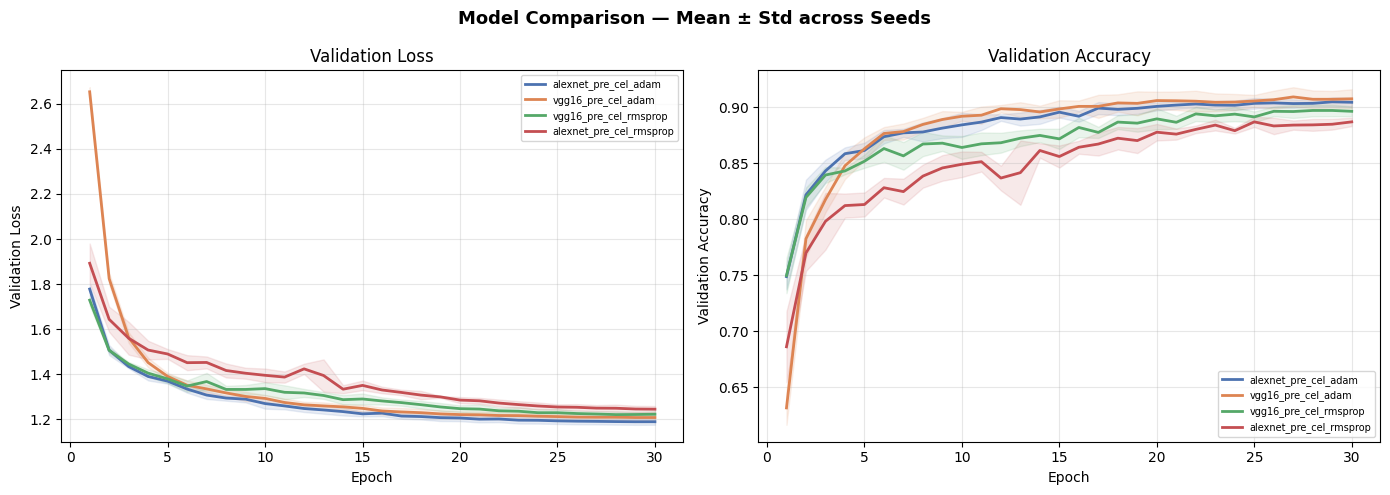

Saved: ../checkpoints_CNN/figures_multiSEED/model_comparison_multiseed.png


In [13]:
def plot_model_comparison(multi_data, save_dir=FIGURES_DIR_MULTI):
    """
    Todos os modelos no mesmo gráfico — mean ± std por modelo.
    Permite comparar directamente a estabilidade e o nível de cada um.
    """
    model_colors = {
        "alexnet_pre_cel_adam"    : "#4C72B0",
        "vgg16_pre_cel_adam"      : "#DD8452",
        "vgg16_pre_cel_rmsprop"   : "#55A868",
        "alexnet_pre_cel_rmsprop" : "#C44E52",
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Model Comparison — Mean ± Std across Seeds", fontsize=13, fontweight="bold")

    for ax, metric_key, ylabel in [
        (axes[0], "val_loss", "Validation Loss"),
        (axes[1], "val_acc",  "Validation Accuracy"),
    ]:
        for model_name, seed_dict in multi_data.items():
            if not seed_dict:
                continue
            curves = [d["history"][metric_key] for d in seed_dict.values()]
            padded = pad_to_same_length(curves)
            mean   = padded.mean(axis=0)
            std    = padded.std(axis=0)
            x      = np.arange(1, len(mean) + 1)
            color  = model_colors.get(model_name, "gray")

            ax.plot(x, mean, color=color, linewidth=2.0, label=model_name)
            ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.12)

        ax.set_title(ylabel)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = save_dir / "model_comparison_multiseed.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {save_path}")

plot_model_comparison(multi_data)